In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
# LLM Configuration - DeepSeek R1 Distill Qwen 7B
LLAMA_STUDIO_API_BASE = os.getenv("LLAMA_STUDIO_API_BASE", "http://localhost:1234/v1")
LLAMA_STUDIO_API_KEY = os.getenv("LLAMA_STUDIO_API_KEY", "lm-studio")
LLM_MODEL_NAME = os.getenv("LLM_MODEL_NAME", "deepseek-r1-distill-qwen-7b")
LLM_TEMPERATURE = float(os.getenv("LLM_TEMPERATURE", "0.7"))
LLM_MAX_TOKENS = int(os.getenv("LLM_MAX_TOKENS", "2048"))
LLM_TIMEOUT = int(os.getenv("LLM_TIMEOUT", "60"))  # Timeout in seconds
LLM_MAX_RETRIES = int(os.getenv("LLM_MAX_RETRIES", "2"))  # Number of retries

In [3]:
model = ChatOpenAI(
        base_url=LLAMA_STUDIO_API_BASE,
        api_key=LLAMA_STUDIO_API_KEY,
        model=LLM_MODEL_NAME,
        temperature=LLM_TEMPERATURE,
        max_tokens=LLM_MAX_TOKENS,
        timeout=LLM_TIMEOUT,
        max_retries=LLM_MAX_RETRIES,
      
    )

In [15]:
#define state   
class BatsmanState(TypedDict):
    runs:int
    sixes:int
    balls:int
    fours:int
    
    sr:float
    bpd:float
    boundary_percent:float
    summary:str
    
   
    

In [20]:
def calculate_sr(state:BatsmanState) -> BatsmanState:
    # fecth title 
    strike_rate   = (state['runs']/state['balls'])*100
     
  
    return {'sr':strike_rate}

def create_bpd(state:BatsmanState) -> BatsmanState:
    bpd   = state['balls']/(state['fours'] + state['sixes'])
    
    return {'bpd':bpd}

def calculate_boundary_percent(state:BatsmanState) -> BatsmanState:
    boundary_percent  =  (((state['fours'] *4)  + (state['sixes'] * 6) )/ state['runs']) * 100
    # state['boundry_percent'] = boundary_percent
    
    return {'boundary_percent':boundary_percent}

def summary(state:BatsmanState) -> BatsmanState:
    summary = f"""strike rate {state['sr']} \n
    Balls per boundary {state['bpd']} \n
    boundary Percentage {state['boundary_percent']} \n"""
    # state['summary'] =summary
    return {'summary':summary}


In [22]:
# define graph 
graph = StateGraph(BatsmanState)

# add nodes
graph.add_node('calculate_sr',calculate_sr)
graph.add_node('create_bpd',create_bpd)
graph.add_node('calculate_boundary_percent',calculate_boundary_percent)
graph.add_node('summary',summary)




# add edges to graph 
graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'create_bpd')
graph.add_edge(START,'calculate_boundary_percent')

graph.add_edge('calculate_sr','summary')
graph.add_edge('create_bpd','summary')
graph.add_edge('calculate_boundary_percent','summary')
graph.add_edge('summary',END)

#compile the graph 
workflow = graph.compile()

# execute the graph

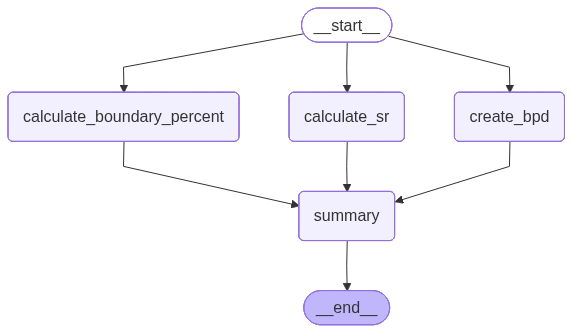

In [23]:
workflow

In [24]:
intital_state = {'runs':100 ,'balls':50,'fours':4,'sixes':6 }
final_state = workflow.invoke(intital_state)
print(final_state['summary'])

strike rate 200.0 

    Balls per boundary 5.0 

    boundary Percentage 52.0 



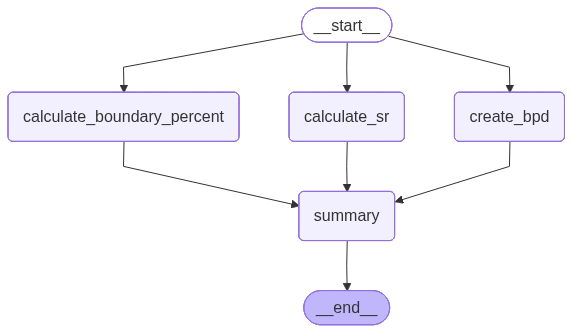

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())